# Diamond Regression Project

This project aims to build a regression model that predicts diamond pricing using core physical and quality features such as carat, cut, color, clarity, and dimensions. It identifies key factors influencing valuation to facilitate data-backed decision-making in the industry.

<img src='https://cdn.shopify.com/s/files/1/0629/0846/5267/files/Orange_Diamonds.webp?v=1771930719' width='750'>

In [1]:
#Libraries
import pandas as pd
pd.set_option('display.max_columns',55) 

import warnings 
warnings.filterwarnings('ignore') 

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import  r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EDA

In [2]:
df=pd.read_csv('diamonds.csv')

In [3]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
df.tail()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,53940,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


In [5]:
df.shape

(53940, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [7]:
df.isnull().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [8]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [9]:
df.corr(numeric_only=True)

,Unnamed: 0,carat,depth,table,price,x,y,z
Unnamed: 0,1.000000,-0.377983,-0.034800,-0.100830,-0.306873,-0.405440,-0.395843,-0.399208
carat,-0.377983,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,-0.034800,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,-0.100830,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,-0.306873,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,-0.405440,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,-0.395843,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,-0.399208,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


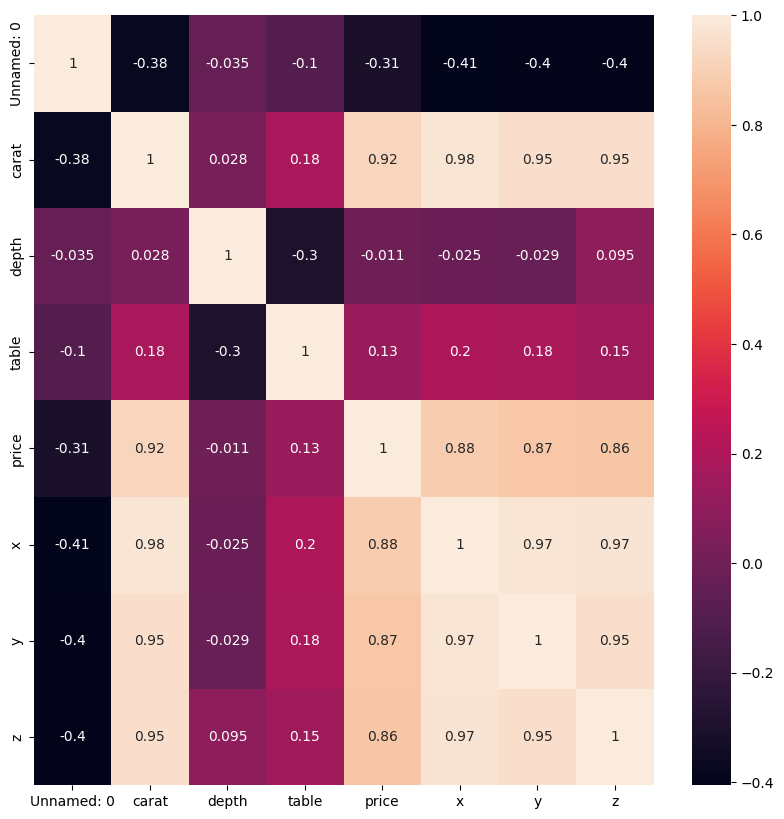

In [14]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True),annot=True);

In [15]:
abs(df.corr(numeric_only=True))['price'].sort_values(ascending=False)

price         1.000000
carat         0.921591
x             0.884435
y             0.865421
z             0.861249
Unnamed: 0    0.306873
table         0.127134
depth         0.010647
Name: price, dtype: float64

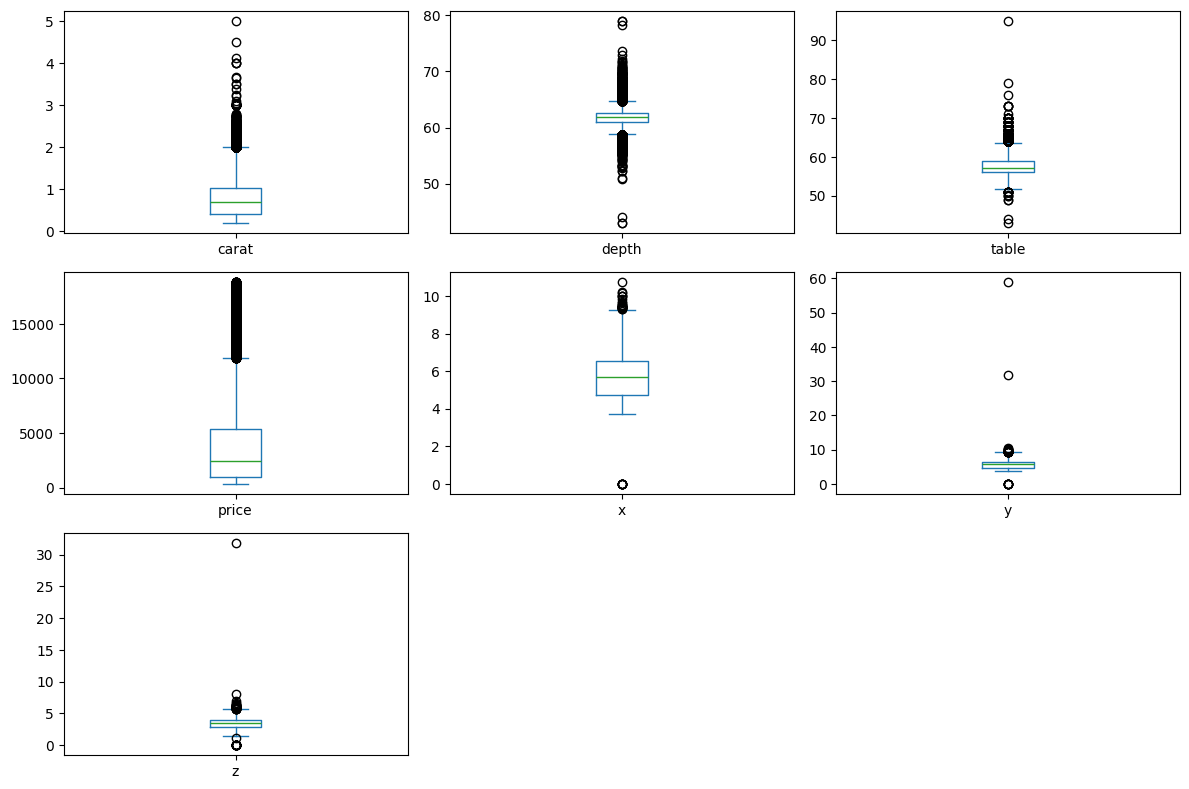

In [17]:
num_cols = ["carat","depth","table","price","x","y","z"]
df[num_cols].plot(
    kind="box",
    subplots=True,
    layout=(3, 3),
    figsize=(12, 8),
    sharex=False,
    sharey=False,
)
plt.tight_layout()
plt.show()

In [18]:
df.drop("Unnamed: 0", axis=1, inplace=True) # delete unnamed

In [19]:
df = df[(df["x"] > 0) & (df["y"] > 0) & (df["z"] > 0)] 

In [20]:
df = df[(df["y"] < 20) & (df["z"] < 10)]

Text(0.5, 1.0, 'Log-Transformed Price (Normal Distribution)')

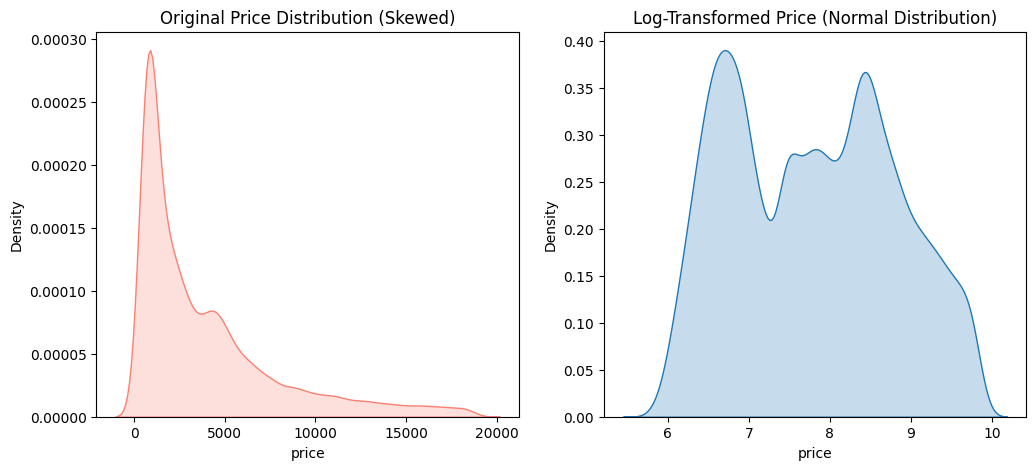

In [21]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(x=df['price'], fill=True, color="salmon")
plt.title("Original Price Distribution (Skewed)")

plt.subplot(1, 2, 2)
sns.kdeplot(x=np.log(df['price']),fill=True)
plt.title("Log-Transformed Price (Normal Distribution)")

### Feature Engineering

In [22]:
df["volume"] = df["x"] * df["y"] * df["z"]

In [24]:
mappings = {
    "cut": {"Fair": 1, "Good": 2, "Very Good": 3, "Premium": 4, "Ideal": 5},
    "color": {"J": 1, "I": 2, "H": 3, "G": 4, "F": 5, "E": 6, "D": 7},
    "clarity": {
        "I1": 1,
        "SI2": 2,
        "SI1": 3,
        "VS2": 4,
        "VS1": 5,
        "VVS2": 6,
        "VVS1": 7,
        "IF": 8,
    },
}

df = df.replace(mappings)

In [25]:
df = df.drop(["cut", "color", "clarity"], axis=1)

In [26]:
x = df.drop(['price'], axis=1)
y = df[['price']]

In [27]:
x.head()

,carat,depth,table,x,y,z,volume
0,0.23,61.5,55.0,3.95,3.98,2.43,38.202030
1,0.21,59.8,61.0,3.89,3.84,2.31,34.505856
2,0.23,56.9,65.0,4.05,4.07,2.31,38.076885
3,0.29,62.4,58.0,4.20,4.23,2.63,46.724580
4,0.31,63.3,58.0,4.34,4.35,2.75,51.917250


In [28]:
x.shape

(53917, 7)

In [29]:
x_train, x_test, y_train, y_test=train_test_split(x,y, random_state=42, test_size=0.20)

### Modeling

In [30]:
lr=LinearRegression()

In [31]:
model=lr.fit(x_train,y_train)

In [32]:
predict=model.predict(x_test)

In [33]:
r2_score(y_test,predict)

0.8684862825679394

In [35]:
mean_squared_error(y_test,predict)**0.5

1439.7126943082797

In [36]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)


def algo_test(x, y):
    # Initialize all regression models
    L = LinearRegression()
    R = Ridge()
    Lass = Lasso()
    E = ElasticNet()
    ETR = ExtraTreeRegressor()
    GBR = GradientBoostingRegressor()
    kn = KNeighborsRegressor()
    dt = DecisionTreeRegressor()
    xgb = XGBRegressor()

    algos = [L, R, Lass, E, ETR, GBR, kn, dt, xgb]
    algo_names = [
        "Linear",
        "Ridge",
        "Lasso",
        "ElasticNet",
        "Extra Tree",
        "Gradient Boosting",
        "KNeighborsRegressor",
        "Decision Tree",
        "XGBRegressor",
    ]

    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42
    )

    r_squared = []
    rmse = []
    mae = []

    # Create a DataFrame to store model performance metrics
    result = pd.DataFrame(
        columns=["R_Squared", "RMSE", "MAE"], index=algo_names
    )

    for algo in algos:
        p = algo.fit(x_train, y_train).predict(x_test)
        r_squared.append(r2_score(y_test, p))
        rmse.append(mean_squared_error(y_test, p) ** 0.5)
        mae.append(mean_absolute_error(y_test, p))

    # Populate the result table with calculated metrics
    result.R_Squared = r_squared
    result.RMSE = rmse
    result.MAE = mae

    # Sort the results by R-Squared in descending order and return
    result_table = result.sort_values("R_Squared", ascending=False)
    return result_table

In [37]:
algo_test(x,y)

,R_Squared,RMSE,MAE
Gradient Boosting,0.888534,1325.446702,760.669603
XGBRegressor,0.885318,1344.427108,761.391296
KNeighborsRegressor,0.872535,1417.377447,805.139021
Ridge,0.868489,1439.697241,850.690618
Linear,0.868486,1439.712694,850.893730
Lasso,0.868408,1440.141970,847.529557
ElasticNet,0.861391,1478.039901,948.401386
Decision Tree,0.791139,1814.343394,1000.530059
Extra Tree,0.776504,1876.831045,1021.128000


### Feature Importance

In [40]:
residuals=y_test-predict

<Axes: xlabel='price', ylabel='Density'>

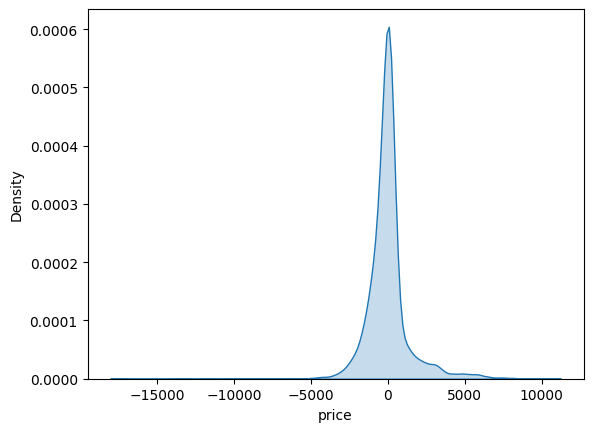

In [41]:
sns.kdeplot(x=residuals['price'], fill=True)

In [42]:
from yellowbrick.regressor import ResidualsPlot

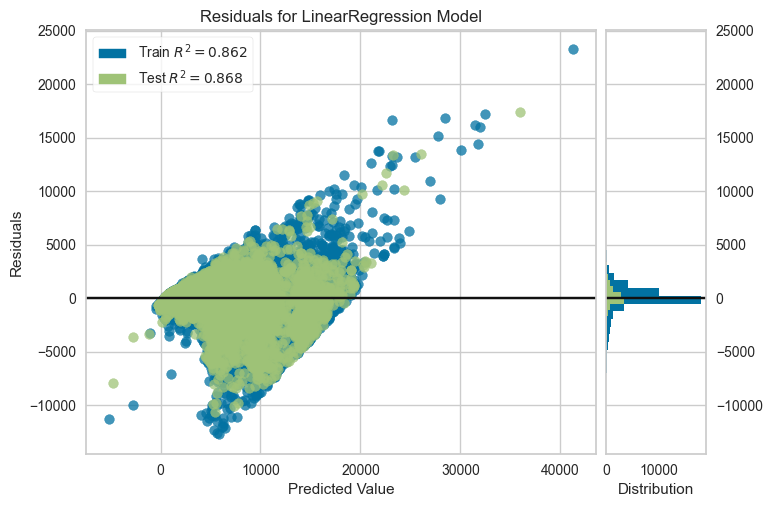

In [43]:
vis=ResidualsPlot(model)
vis.fit(x_train,y_train)
vis.score(x_test,y_test)
vis.show();

In [44]:
df.to_pickle('kc_diamond.pkl')

In [45]:
import joblib

In [46]:
joblib.dump(model,'diamond_regression.pkl')

['diamond_regression.pkl']

This study examines the core determinants of diamond valuation, emphasizing the impact of carat weight and spatial dimensions. Following thorough data preprocessing and feature engineering, multiple regression models were benchmarked. The empirical results demonstrate that ensemble learning yields strong predictive performance, with the Gradient Boosting Regressor emerging as the top model ($R^2 = 0.8885$).